# Jelly Babies: Paper-Scissors-Stone Simulation

This notebook simulates the game described in the prompt for two rule sets:

- **(a) Elimination:** if a child reaches 0 sweets, they are eliminated.
- **(b) Zero beats positive:** a child with 0 sweets automatically wins against a child with sweets.

The code below is written so you can change the number of children, the number of sweets per child, the number of rounds, and the number of trials.

## Model details

- There are `n` children, indexed by age (0 = oldest).
- Each round consists of **n games**: children act in age order, each choosing a random opponent.
- For each game, outcomes are equally likely: win / lose / draw.
- A win transfers exactly one sweet from loser to winner (unless the loser has 0 in case b).


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Plot output folders (base model)
PLOT_DIRS = {
    'orig_a': Path('original case a'),
    'orig_b': Path('original case b'),
}
for _p in PLOT_DIRS.values():
    _p.mkdir(parents=True, exist_ok=True)

def save_plot(filename, group, dpi=200):
    path = PLOT_DIRS[group] / filename
    plt.savefig(path, dpi=dpi, bbox_inches='tight')

# For reproducibility in the examples below
GLOBAL_SEED = 12345


In [32]:
# --- Global run mode ---
TESTING_MODE = True

if TESTING_MODE:
    # Fast defaults for quick iteration
    trials_baseline = 400
    grid_trials = 120
    case_b_rounds = 60000
    case_b_burn_in = 500

    graphs_trials_hist = 600
    graphs_trials_mean = 120
    graphs_rounds_trace = 200
    graphs_rounds_samples = 2000
    graphs_rounds_extremes = 40000
    graphs_burn_in = 500
else:
    # Slower defaults for smoother estimates
    trials_baseline = 2000
    grid_trials = 400
    case_b_rounds = 400000
    case_b_burn_in = 2000

    graphs_trials_hist = 2000
    graphs_trials_mean = 250
    graphs_rounds_trace = 600
    graphs_rounds_samples = 6000
    graphs_rounds_extremes = 150000
    graphs_burn_in = 2000


In [33]:
def simulate_case_a(n=4, sweets=10, rng=None):
    """Simulate rule set (a). Returns number of rounds until one child remains."""
    if rng is None:
        rng = np.random.default_rng()

    counts = np.full(n, sweets, dtype=int)
    alive = np.ones(n, dtype=bool)
    rounds = 0

    while alive.sum() > 1:
        for i in range(n):
            if not alive[i]:
                continue
            alive_idx = np.flatnonzero(alive)
            if len(alive_idx) <= 1:
                break
            # choose opponent uniformly from alive excluding i
            candidates = alive_idx[alive_idx != i]
            j = rng.choice(candidates)

            outcome = rng.integers(3)  # 0: i wins, 1: j wins, 2: draw
            if outcome == 0:
                counts[i] += 1
                counts[j] -= 1
                if counts[j] == 0:
                    alive[j] = False
            elif outcome == 1:
                counts[j] += 1
                counts[i] -= 1
                if counts[i] == 0:
                    alive[i] = False

            if alive.sum() <= 1:
                break
        rounds += 1
    return rounds


def average_rounds_case_a(n=4, sweets=10, trials=1000, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    results = [simulate_case_a(n=n, sweets=sweets, rng=rng) for _ in range(trials)]
    return float(np.mean(results)), float(np.std(results, ddof=0))


## Case (a): Elimination

In [34]:
# Baseline: 4 children, 10 sweets each
mean_rounds, std_rounds = average_rounds_case_a(n=4, sweets=10, trials=trials_baseline)
mean_rounds, std_rounds


(388.67, 269.2330609342025)

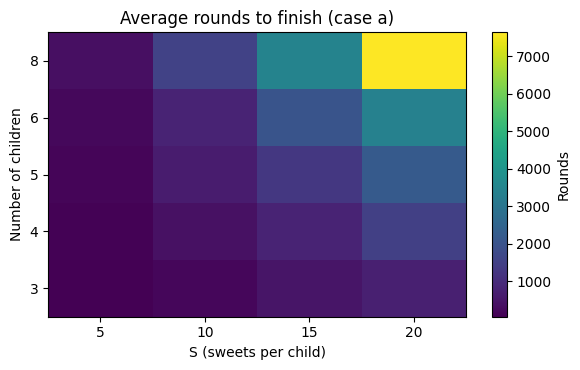

In [35]:
# Explore how the duration varies with n and sweets
n_values = [3, 4, 5, 6, 8]
s_values = [5, 10, 15, 20]
trials = grid_trials  # increase for smoother estimates

avg = np.zeros((len(n_values), len(s_values)))
std = np.zeros_like(avg)

for i, n in enumerate(n_values):
    for j, s in enumerate(s_values):
        m, st = average_rounds_case_a(n=n, sweets=s, trials=trials, seed=GLOBAL_SEED + i * 100 + j)
        avg[i, j] = m
        std[i, j] = st

fig, ax = plt.subplots(figsize=(6, 3.8))
im = ax.imshow(avg, origin='lower', aspect='auto')
ax.set_xticks(range(len(s_values)), labels=s_values)
ax.set_yticks(range(len(n_values)), labels=n_values)
ax.set_xlabel('S (sweets per child)')
ax.set_ylabel('N (number of children)')
fig.colorbar(im, ax=ax, label='R (rounds)')
plt.tight_layout()
save_plot('case_a_duration_heatmap.png', 'orig_a')


## Case (b): Zero beats positive

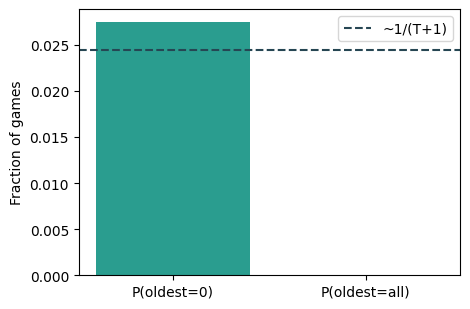

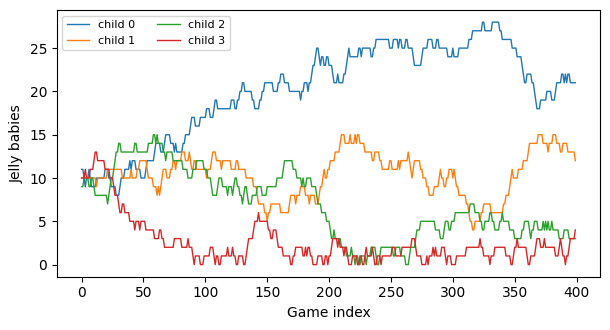

In [36]:
def simulate_case_b(n=4, sweets=10, rounds=200000, burn_in=2000, seed=GLOBAL_SEED):
    """Simulate rule set (b). Returns fraction of games oldest has 0 or all sweets."""
    rng = np.random.default_rng(seed)
    counts = np.full(n, sweets, dtype=int)
    total = n * sweets

    zero = 0
    all_sweets = 0
    games = 0

    for r in range(rounds):
        for i in range(n):
            # choose opponent uniformly from all other children
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1

            ci, cj = counts[i], counts[j]
            if ci == 0 and cj > 0:
                counts[i] += 1
                counts[j] -= 1
            elif cj == 0 and ci > 0:
                counts[j] += 1
                counts[i] -= 1
            elif ci == 0 and cj == 0:
                pass
            else:
                outcome = rng.integers(3)
                if outcome == 0:
                    counts[i] += 1
                    counts[j] -= 1
                elif outcome == 1:
                    counts[j] += 1
                    counts[i] -= 1

            if r >= burn_in:
                games += 1
                if counts[0] == 0:
                    zero += 1
                if counts[0] == total:
                    all_sweets += 1

    return zero / games, all_sweets / games


zero_frac, all_frac = simulate_case_b(n=4, sweets=10, rounds=case_b_rounds, burn_in=case_b_burn_in)
zero_frac, all_frac

# --- Case (b): fraction at zero / all sweets (visual) ---
total = 4 * 10
expected = 1 / (total + 1)
plt.figure(figsize=(4.8, 3.2))
plt.bar(['P(oldest=0)', 'P(oldest=all)'], [zero_frac, all_frac], color=['#2a9d8f', '#e76f51'])
plt.axhline(expected, color='#264653', linestyle='--', label='~1/(T+1)')
plt.ylabel('Fraction of games')
plt.legend()
plt.tight_layout()
save_plot('case_b_extremes_bar.png', 'orig_b')

# --- Case (b): all players time series (illustrates boundary effects) ---
def simulate_case_b_all_traces(n=4, sweets=10, rounds=6000, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    counts = np.full(n, sweets, dtype=int)
    traces = [[] for _ in range(n)]
    for r in range(rounds):
        for i in range(n):
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1
            ci, cj = counts[i], counts[j]
            if ci == 0 and cj > 0:
                counts[i] += 1
                counts[j] -= 1
            elif cj == 0 and ci > 0:
                counts[j] += 1
                counts[i] -= 1
            elif ci == 0 and cj == 0:
                pass
            else:
                outcome = rng.integers(3)
                if outcome == 0:
                    counts[i] += 1
                    counts[j] -= 1
                elif outcome == 1:
                    counts[j] += 1
                    counts[i] -= 1
            for k in range(n):
                traces[k].append(counts[k])
    return np.array(traces)

traces = simulate_case_b_all_traces(n=4, sweets=10, rounds=800, seed=GLOBAL_SEED + 99)
plt.figure(figsize=(6.2, 3.4))
for k in range(traces.shape[0]):
    plt.plot(traces[k][:400], lw=1.0, label=f'child {k}')
plt.xlabel('Game index')
plt.ylabel('Jelly babies')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
save_plot('case_b_all_players_trace.png', 'orig_b')

### Explanation (case b)

**Short math intuition** (for `n` children, total sweets `T = n*sweets`):

- Focus on the oldest child’s sweet count `X_t`. Between games it changes by `+1`, `-1`, or `0`.
- When `1 <= X_t <= T-1`, outcomes are symmetric (win/lose/draw are equally likely), so the drift is ~0.
- At the boundaries the rule changes: if `X_t = 0`, the next time they meet someone with sweets they must gain 1 (so 0 is **reflecting**). If `X_t = T`, the next time a zero plays them they must lose 1 (so `T` is also effectively reflecting).
- A symmetric random walk with reflecting boundaries has a **near‑uniform stationary distribution** over `0..T`. That gives the approximation
  `P(X_t = 0) ≈ P(X_t = T) ≈ 1/(T+1)`.
- For the default `n=4`, `T=40`, this predicts about `1/41 ≈ 0.0244`, which matches the simulation (≈0.025).

This isn’t an exact proof for the full multi‑player chain, but symmetry + reflecting boundaries makes the approximation very accurate in practice.


## Additional graphs

Run this single cell to generate all additional plots. Adjust the speed knobs at the top for faster or more accurate results.

### Additional graphs: case (a)

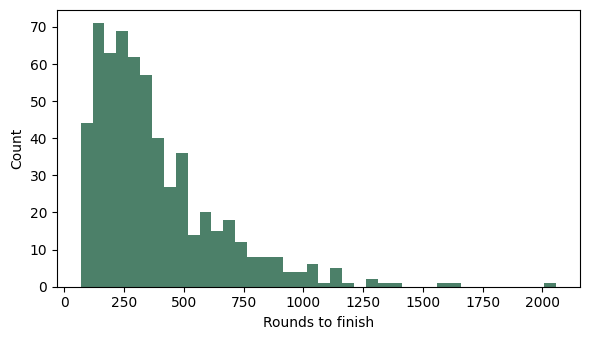

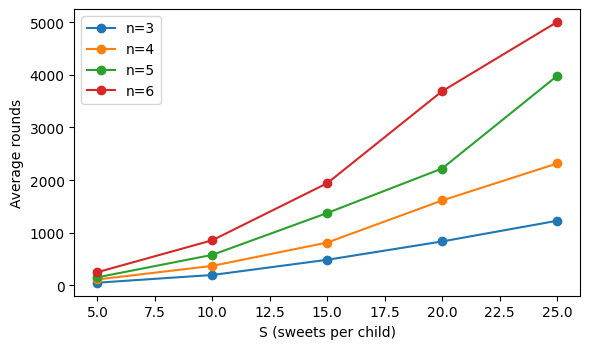

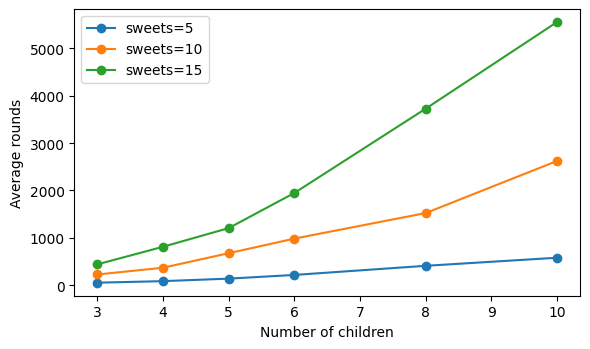

In [37]:
# --- Uses global TESTING_MODE presets ---
trials_hist = graphs_trials_hist
trials_mean = graphs_trials_mean
rounds_trace = graphs_rounds_trace
rounds_samples = graphs_rounds_samples
rounds_extremes = graphs_rounds_extremes
burn_in = graphs_burn_in
seed = GLOBAL_SEED



# --- Case (a): duration distribution ---
rng = np.random.default_rng(seed)
durations = [simulate_case_a(n=4, sweets=10, rng=rng) for _ in range(trials_hist)]

plt.figure(figsize=(6, 3.5))
plt.hist(durations, bins=40, color='#2d6a4f', alpha=0.85)
plt.xlabel('R (rounds to finish)')
plt.ylabel('Count')
plt.tight_layout()
save_plot('case_a_duration_hist.png', 'orig_a')

# --- Case (a): mean duration vs sweets per child ---
s_values = [5, 10, 15, 20, 25]
n_values = [3, 4, 5, 6]
means_by_n = {}

for n in n_values:
    means = []
    for s in s_values:
        m, _ = average_rounds_case_a(n=n, sweets=s, trials=trials_mean, seed=seed + 1000 + 13 * n + s)
        means.append(m)
    means_by_n[n] = means

plt.figure(figsize=(6, 3.6))
for n, means in means_by_n.items():
    plt.plot(s_values, means, marker='o', label=f'n={n}')
plt.xlabel('S (sweets per child)')
plt.ylabel('R (average rounds)')
plt.legend()
plt.tight_layout()
save_plot('case_a_mean_vs_sweets.png', 'orig_a')

# --- Case (a): mean duration vs number of children ---
n_values2 = [3, 4, 5, 6, 8, 10]
s_values2 = [5, 10, 15]
means_by_s = {}

for s in s_values2:
    means = []
    for n in n_values2:
        m, _ = average_rounds_case_a(n=n, sweets=s, trials=trials_mean, seed=seed + 2000 + 17 * n + s)
        means.append(m)
    means_by_s[s] = means

plt.figure(figsize=(6, 3.6))
for s, means in means_by_s.items():
    plt.plot(n_values2, means, marker='o', label=f'sweets={s}')
plt.xlabel('N (number of children)')
plt.ylabel('R (average rounds)')
plt.legend()
plt.tight_layout()
save_plot('case_a_mean_vs_children.png', 'orig_a')


### Additional graphs: case (b)

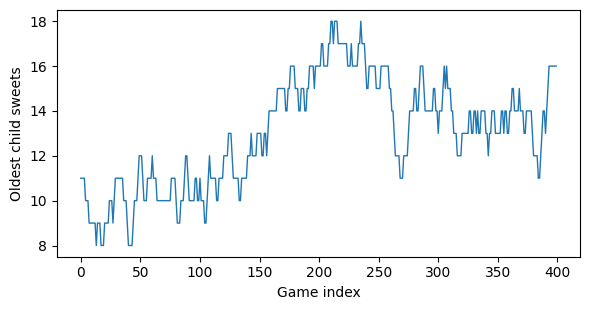

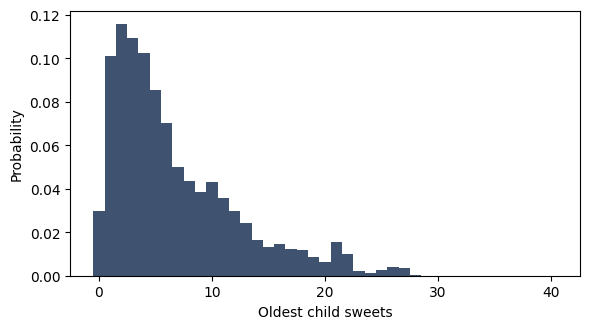

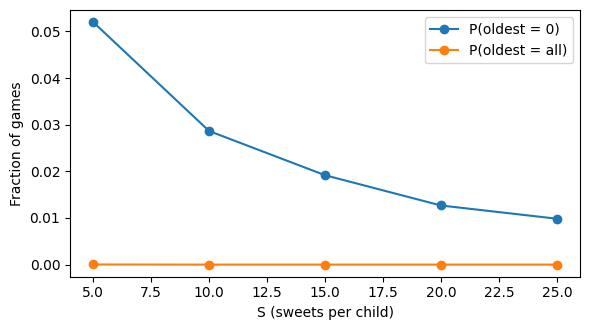

In [38]:
# --- Uses global TESTING_MODE presets ---
trials_hist = graphs_trials_hist
trials_mean = graphs_trials_mean
rounds_trace = graphs_rounds_trace
rounds_samples = graphs_rounds_samples
rounds_extremes = graphs_rounds_extremes
burn_in = graphs_burn_in
seed = GLOBAL_SEED

# --- Adjustable parameters for case (b) plots ---
n_b = 4
sweets_b = 10
trace_games = 400  # number of games to show from the trace
s_values_b = [5, 10, 15, 20, 25]

# --- Single simulation to drive all case (b) plots (n_b, sweets_b) ---
def simulate_case_b_bundle(n=4, sweets=10, rounds=6000, burn_in=2000, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    counts = np.full(n, sweets, dtype=int)
    total = n * sweets

    trace = []
    samples = []
    zero_count = 0
    all_count = 0
    games = 0

    for r in range(rounds):
        for i in range(n):
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1

            ci, cj = counts[i], counts[j]
            if ci == 0 and cj > 0:
                counts[i] += 1
                counts[j] -= 1
            elif cj == 0 and ci > 0:
                counts[j] += 1
                counts[i] -= 1
            elif ci == 0 and cj == 0:
                pass
            else:
                outcome = rng.integers(3)
                if outcome == 0:
                    counts[i] += 1
                    counts[j] -= 1
                elif outcome == 1:
                    counts[j] += 1
                    counts[i] -= 1

            trace.append(counts[0])

            if r >= burn_in:
                games += 1
                samples.append(counts[0])
                if counts[0] == 0:
                    zero_count += 1
                if counts[0] == total:
                    all_count += 1

    zero_frac = zero_count / games if games else 0.0
    all_frac = all_count / games if games else 0.0
    return np.array(trace), np.array(samples), zero_frac, all_frac


trace, samples, zero_frac, all_frac = simulate_case_b_bundle(
    n=n_b,
    sweets=sweets_b,
    rounds=rounds_samples,
    burn_in=burn_in,
    seed=seed,
)

# --- Case (b): time series ---
plt.figure(figsize=(6, 3.2))
plt.plot(trace[:trace_games], lw=1.0)
plt.xlabel('Game index')
plt.ylabel('Oldest child sweets')
plt.tight_layout()
save_plot('case_b_oldest_trace.png', 'orig_b')

# --- Case (b): stationary distribution ---
total = n_b * sweets_b
bins = np.arange(-0.5, total + 1.5, 1)

plt.figure(figsize=(6, 3.4))
plt.hist(samples, bins=bins, density=True, color='#1d3557', alpha=0.85)
plt.xlabel('Oldest child sweets')
plt.ylabel('Probability')
plt.tight_layout()
save_plot('case_b_stationary_distribution.png', 'orig_b')

# --- Case (b): fraction at zero / all sweets vs sweets per child ---
zero_fracs = []
all_fracs = []
for s in s_values_b:
    _, _, z, a = simulate_case_b_bundle(
        n=n_b,
        sweets=s,
        rounds=rounds_extremes,
        burn_in=burn_in,
        seed=seed + 3000 + s,
    )
    zero_fracs.append(z)
    all_fracs.append(a)

plt.figure(figsize=(6, 3.4))
plt.plot(s_values_b, zero_fracs, marker='o', label='P(oldest = 0)')
plt.plot(s_values_b, all_fracs, marker='o', label='P(oldest = all)')
plt.xlabel('S (sweets per child)')
plt.ylabel('Fraction of games')
plt.legend()
plt.tight_layout()
save_plot('case_b_extremes_vs_sweets.png', 'orig_b')


## Extension: Rock Paper Scissors Lizard Spock (stand‑alone)

This block is self‑contained. You can run from here down without running earlier cells.


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Plot output folders (RPSLS extension)
EXT_PLOT_DIRS = {
    'a': Path('extension case a'),
    'b': Path('extension case b'),
}
for _p in EXT_PLOT_DIRS.values():
    _p.mkdir(parents=True, exist_ok=True)

def save_ext_plot(filename, group, dpi=200):
    path = EXT_PLOT_DIRS[group] / filename
    plt.savefig(path, dpi=dpi, bbox_inches='tight')

# --- Extension run mode (stand‑alone) ---
RPSLS_TESTING_MODE = True

if RPSLS_TESTING_MODE:
    # Fast defaults
    ext_trials_baseline = 300
    ext_grid_trials = 120
    ext_case_b_rounds = 50000
    ext_case_b_burn_in = 500
else:
    # Slower, smoother defaults
    ext_trials_baseline = 1500
    ext_grid_trials = 400
    ext_case_b_rounds = 300000
    ext_case_b_burn_in = 2000

# --- Gesture rules (RPSLS) ---
GESTURES = ['rock', 'paper', 'scissors', 'lizard', 'spock']
# Each gesture beats the two listed
WINS_AGAINST = {
    'rock': {'scissors', 'lizard'},
    'paper': {'rock', 'spock'},
    'scissors': {'paper', 'lizard'},
    'lizard': {'paper', 'spock'},
    'spock': {'scissors', 'rock'},
}

def rpsls_outcome(a, b, rng):
    """Return 0 if a wins, 1 if b wins, 2 for draw."""
    if a == b:
        return 2
    if b in WINS_AGAINST[a]:
        return 0
    return 1

def play_rpsls(rng):
    a = rng.choice(GESTURES)
    b = rng.choice(GESTURES)
    return rpsls_outcome(a, b, rng)

# --- Case (a): elimination ---
def simulate_rpsls_case_a(n=4, sweets=10, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    counts = np.full(n, sweets, dtype=int)
    alive = np.ones(n, dtype=bool)
    rounds = 0
    while alive.sum() > 1:
        for i in range(n):
            if not alive[i]:
                continue
            alive_idx = np.flatnonzero(alive)
            if len(alive_idx) <= 1:
                break
            candidates = alive_idx[alive_idx != i]
            j = rng.choice(candidates)
            outcome = play_rpsls(rng)
            if outcome == 0:
                counts[i] += 1
                counts[j] -= 1
                if counts[j] == 0:
                    alive[j] = False
            elif outcome == 1:
                counts[j] += 1
                counts[i] -= 1
                if counts[i] == 0:
                    alive[i] = False
            if alive.sum() <= 1:
                break
        rounds += 1
    return rounds

def average_rounds_rpsls_case_a(n=4, sweets=10, trials=500, seed=123):
    rng = np.random.default_rng(seed)
    results = [simulate_rpsls_case_a(n=n, sweets=sweets, rng=rng) for _ in range(trials)]
    return float(np.mean(results)), float(np.std(results, ddof=0))

# --- Case (b): zero beats positive ---
def simulate_rpsls_case_b(n=4, sweets=10, rounds=200000, burn_in=2000, seed=123):
    rng = np.random.default_rng(seed)
    counts = np.full(n, sweets, dtype=int)
    total = n * sweets
    zero = 0
    all_sweets = 0
    games = 0
    for r in range(rounds):
        for i in range(n):
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1
            ci, cj = counts[i], counts[j]
            if ci == 0 and cj > 0:
                counts[i] += 1
                counts[j] -= 1
            elif cj == 0 and ci > 0:
                counts[j] += 1
                counts[i] -= 1
            elif ci == 0 and cj == 0:
                pass
            else:
                outcome = play_rpsls(rng)
                if outcome == 0:
                    counts[i] += 1
                    counts[j] -= 1
                elif outcome == 1:
                    counts[j] += 1
                    counts[i] -= 1
            if r >= burn_in:
                games += 1
                if counts[0] == 0:
                    zero += 1
                if counts[0] == total:
                    all_sweets += 1
    return zero / games, all_sweets / games

# --- Quick outputs (edit these parameters freely) ---
mean_rounds, std_rounds = average_rounds_rpsls_case_a(n=4, sweets=10, trials=ext_trials_baseline)
mean_rounds, std_rounds

zero_frac, all_frac = simulate_rpsls_case_b(n=4, sweets=10, rounds=ext_case_b_rounds, burn_in=ext_case_b_burn_in)
zero_frac, all_frac


(0.029292929292929294, 0.0)

### Extension plots (RPSLS)

These are optional and use the same stand‑alone functions above.

KeyboardInterrupt: 

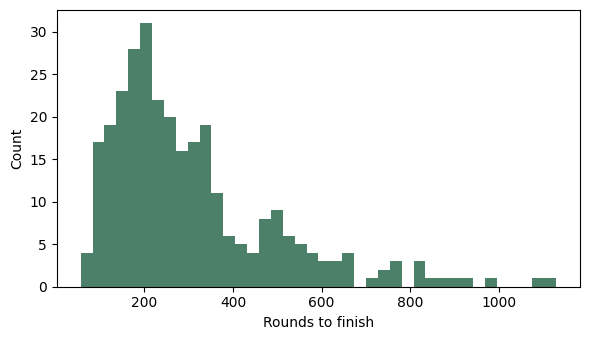

In [40]:
# Case (a): duration distribution (RPSLS)
trials_hist = ext_trials_baseline
rng = np.random.default_rng(3001)
durations = [simulate_rpsls_case_a(n=4, sweets=10, rng=rng) for _ in range(trials_hist)]

plt.figure(figsize=(6, 3.5))
plt.hist(durations, bins=40, color='#2d6a4f', alpha=0.85)
plt.xlabel('R (rounds to finish)')
plt.ylabel('Count')
plt.tight_layout()
save_ext_plot('rpsls_case_a_duration_hist.png', 'a')

# Case (a): average duration vs sweets per child (RPSLS)
s_values = [5, 10, 15, 20, 25]
n_values = [3, 4, 5, 6]
means_by_n = {}

for n in n_values:
    means = []
    for s in s_values:
        m, _ = average_rounds_rpsls_case_a(n=n, sweets=s, trials=ext_grid_trials, seed=4000 + 13 * n + s)
        means.append(m)
    means_by_n[n] = means

plt.figure(figsize=(6, 3.6))
for n, means in means_by_n.items():
    plt.plot(s_values, means, marker='o', label=f'n={n}')
plt.xlabel('S (sweets per child)')
plt.ylabel('R (average rounds)')
plt.legend()
plt.tight_layout()
save_ext_plot('rpsls_case_a_mean_vs_sweets.png', 'a')

# Case (a): average duration vs number of children (RPSLS)
n_values2 = [3, 4, 5, 6, 8, 10]
s_values2 = [5, 10, 15]
means_by_s = {}

for s in s_values2:
    means = []
    for n in n_values2:
        m, _ = average_rounds_rpsls_case_a(n=n, sweets=s, trials=ext_grid_trials, seed=5000 + 17 * n + s)
        means.append(m)
    means_by_s[s] = means

plt.figure(figsize=(6, 3.6))
for s, means in means_by_s.items():
    plt.plot(n_values2, means, marker='o', label=f'sweets={s}')
plt.xlabel('N (number of children)')
plt.ylabel('R (average rounds)')
plt.legend()
plt.tight_layout()
save_ext_plot('rpsls_case_a_mean_vs_children.png', 'a')

# Case (b): single-run bundle for trace + stationary + extremes (RPSLS)
def simulate_rpsls_case_b_bundle(n=4, sweets=10, rounds=6000, burn_in=2000, seed=123):
    rng = np.random.default_rng(seed)
    counts = np.full(n, sweets, dtype=int)
    total = n * sweets
    trace = []
    samples = []
    zero_count = 0
    all_count = 0
    games = 0
    for r in range(rounds):
        for i in range(n):
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1
            ci, cj = counts[i], counts[j]
            if ci == 0 and cj > 0:
                counts[i] += 1
                counts[j] -= 1
            elif cj == 0 and ci > 0:
                counts[j] += 1
                counts[i] -= 1
            elif ci == 0 and cj == 0:
                pass
            else:
                outcome = play_rpsls(rng)
                if outcome == 0:
                    counts[i] += 1
                    counts[j] -= 1
                elif outcome == 1:
                    counts[j] += 1
                    counts[i] -= 1
            trace.append(counts[0])
            if r >= burn_in:
                games += 1
                samples.append(counts[0])
                if counts[0] == 0:
                    zero_count += 1
                if counts[0] == total:
                    all_count += 1
    zero_frac = zero_count / games if games else 0.0
    all_frac = all_count / games if games else 0.0
    return np.array(trace), np.array(samples), zero_frac, all_frac

# Adjustable parameters for RPSLS case (b) plots
n_b = 4
sweets_b = 10
trace_games = 400
s_values_b = [5, 10, 15, 20, 25]

trace, samples, zero_frac, all_frac = simulate_rpsls_case_b_bundle(
    n=n_b,
    sweets=sweets_b,
    rounds=ext_case_b_rounds,
    burn_in=ext_case_b_burn_in,
    seed=6000,
)

plt.figure(figsize=(6, 3.2))
plt.plot(trace[:trace_games], lw=1.0)
plt.xlabel('Game index')
plt.ylabel('Oldest child sweets')
plt.tight_layout()
save_ext_plot('rpsls_case_b_oldest_trace.png', 'b')

total = n_b * sweets_b
bins = np.arange(-0.5, total + 1.5, 1)

plt.figure(figsize=(6, 3.4))
plt.hist(samples, bins=bins, density=True, color='#1d3557', alpha=0.85)
plt.xlabel('Oldest child sweets')
plt.ylabel('Probability')
plt.tight_layout()
expected = 1 / (total + 1)
plt.axhline(expected, color='#264653', linestyle='--', label='~1/(T+1)')
plt.legend()
plt.tight_layout()
save_ext_plot('rpsls_case_b_stationary_distribution.png', 'b')

zero_fracs = []
all_fracs = []
for s in s_values_b:
    _, _, z, a = simulate_rpsls_case_b_bundle(
        n=n_b,
        sweets=s,
        rounds=ext_case_b_rounds,
        burn_in=ext_case_b_burn_in,
        seed=7000 + s,
    )
    zero_fracs.append(z)
    all_fracs.append(a)

plt.figure(figsize=(6, 3.4))
plt.plot(s_values_b, zero_fracs, marker='o', label='P(oldest = 0)')
plt.plot(s_values_b, all_fracs, marker='o', label='P(oldest = all)')
plt.xlabel('S (sweets per child)')
plt.ylabel('Fraction of games')
plt.legend()
plt.tight_layout()
save_ext_plot('rpsls_case_b_extremes_vs_sweets.png', 'b')

# Case (b): all players time series (RPSLS)
def simulate_rpsls_case_b_all_traces(n=4, sweets=10, rounds=6000, seed=123):
    rng = np.random.default_rng(seed)
    counts = np.full(n, sweets, dtype=int)
    traces = [[] for _ in range(n)]
    for r in range(rounds):
        for i in range(n):
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1
            ci, cj = counts[i], counts[j]
            if ci == 0 and cj > 0:
                counts[i] += 1
                counts[j] -= 1
            elif cj == 0 and ci > 0:
                counts[j] += 1
                counts[i] -= 1
            elif ci == 0 and cj == 0:
                pass
            else:
                outcome = play_rpsls(rng)
                if outcome == 0:
                    counts[i] += 1
                    counts[j] -= 1
                elif outcome == 1:
                    counts[j] += 1
                    counts[i] -= 1
            for k in range(n):
                traces[k].append(counts[k])
    return np.array(traces)

traces = simulate_rpsls_case_b_all_traces(n=n_b, sweets=sweets_b, rounds=800, seed=8001)
plt.figure(figsize=(6.2, 3.4))
for k in range(traces.shape[0]):
    plt.plot(traces[k][:400], lw=1.0, label=f'child {k}')
plt.xlabel('Game index')
plt.ylabel('Jelly babies')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
save_ext_plot('rpsls_case_b_all_players_trace.png', 'b')
